In [2]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
def load_sir(rate: float) -> pd.DataFrame:
    filename = f"../output/stats-musae_git_edges-SIR-I=   {rate:.5f}-R=   1.00000-S={42072}.dat"
    df = pd.read_csv(filename, sep=r'\s+', header=None, comment='#',
                    names=['t','idens', 'rdens', 'irate', 'rrate'], 
                    engine='python')
    df['sdens'] = 1 - df['rdens'] - df['idens']
    return df

df1 = load_sir(0.5)
df2 = load_sir(1)
df3 = load_sir(1.5)
df4 = load_sir(2)

In [8]:
df1

,t,idens,rdens,irate,rrate,sdens
0,0.000434,0.000053,0.000000,4729.0,1.0,0.999947
1,0.000473,0.000080,0.000000,4732.5,2.0,0.999920
2,0.000931,0.000106,0.000000,4735.5,3.0,0.999894
3,0.000981,0.000133,0.000000,4737.5,4.0,0.999867
4,0.001032,0.000159,0.000000,4742.5,5.0,0.999841
...,...,...,...,...,...,...
58649,10.152737,0.000080,0.777825,0.0,4.0,0.222095
58650,10.863882,0.000053,0.777851,0.0,3.0,0.222095
58651,11.170135,0.000027,0.777878,0.0,2.0,0.222095
58652,11.485671,0.000000,0.777905,0.0,1.0,0.222095


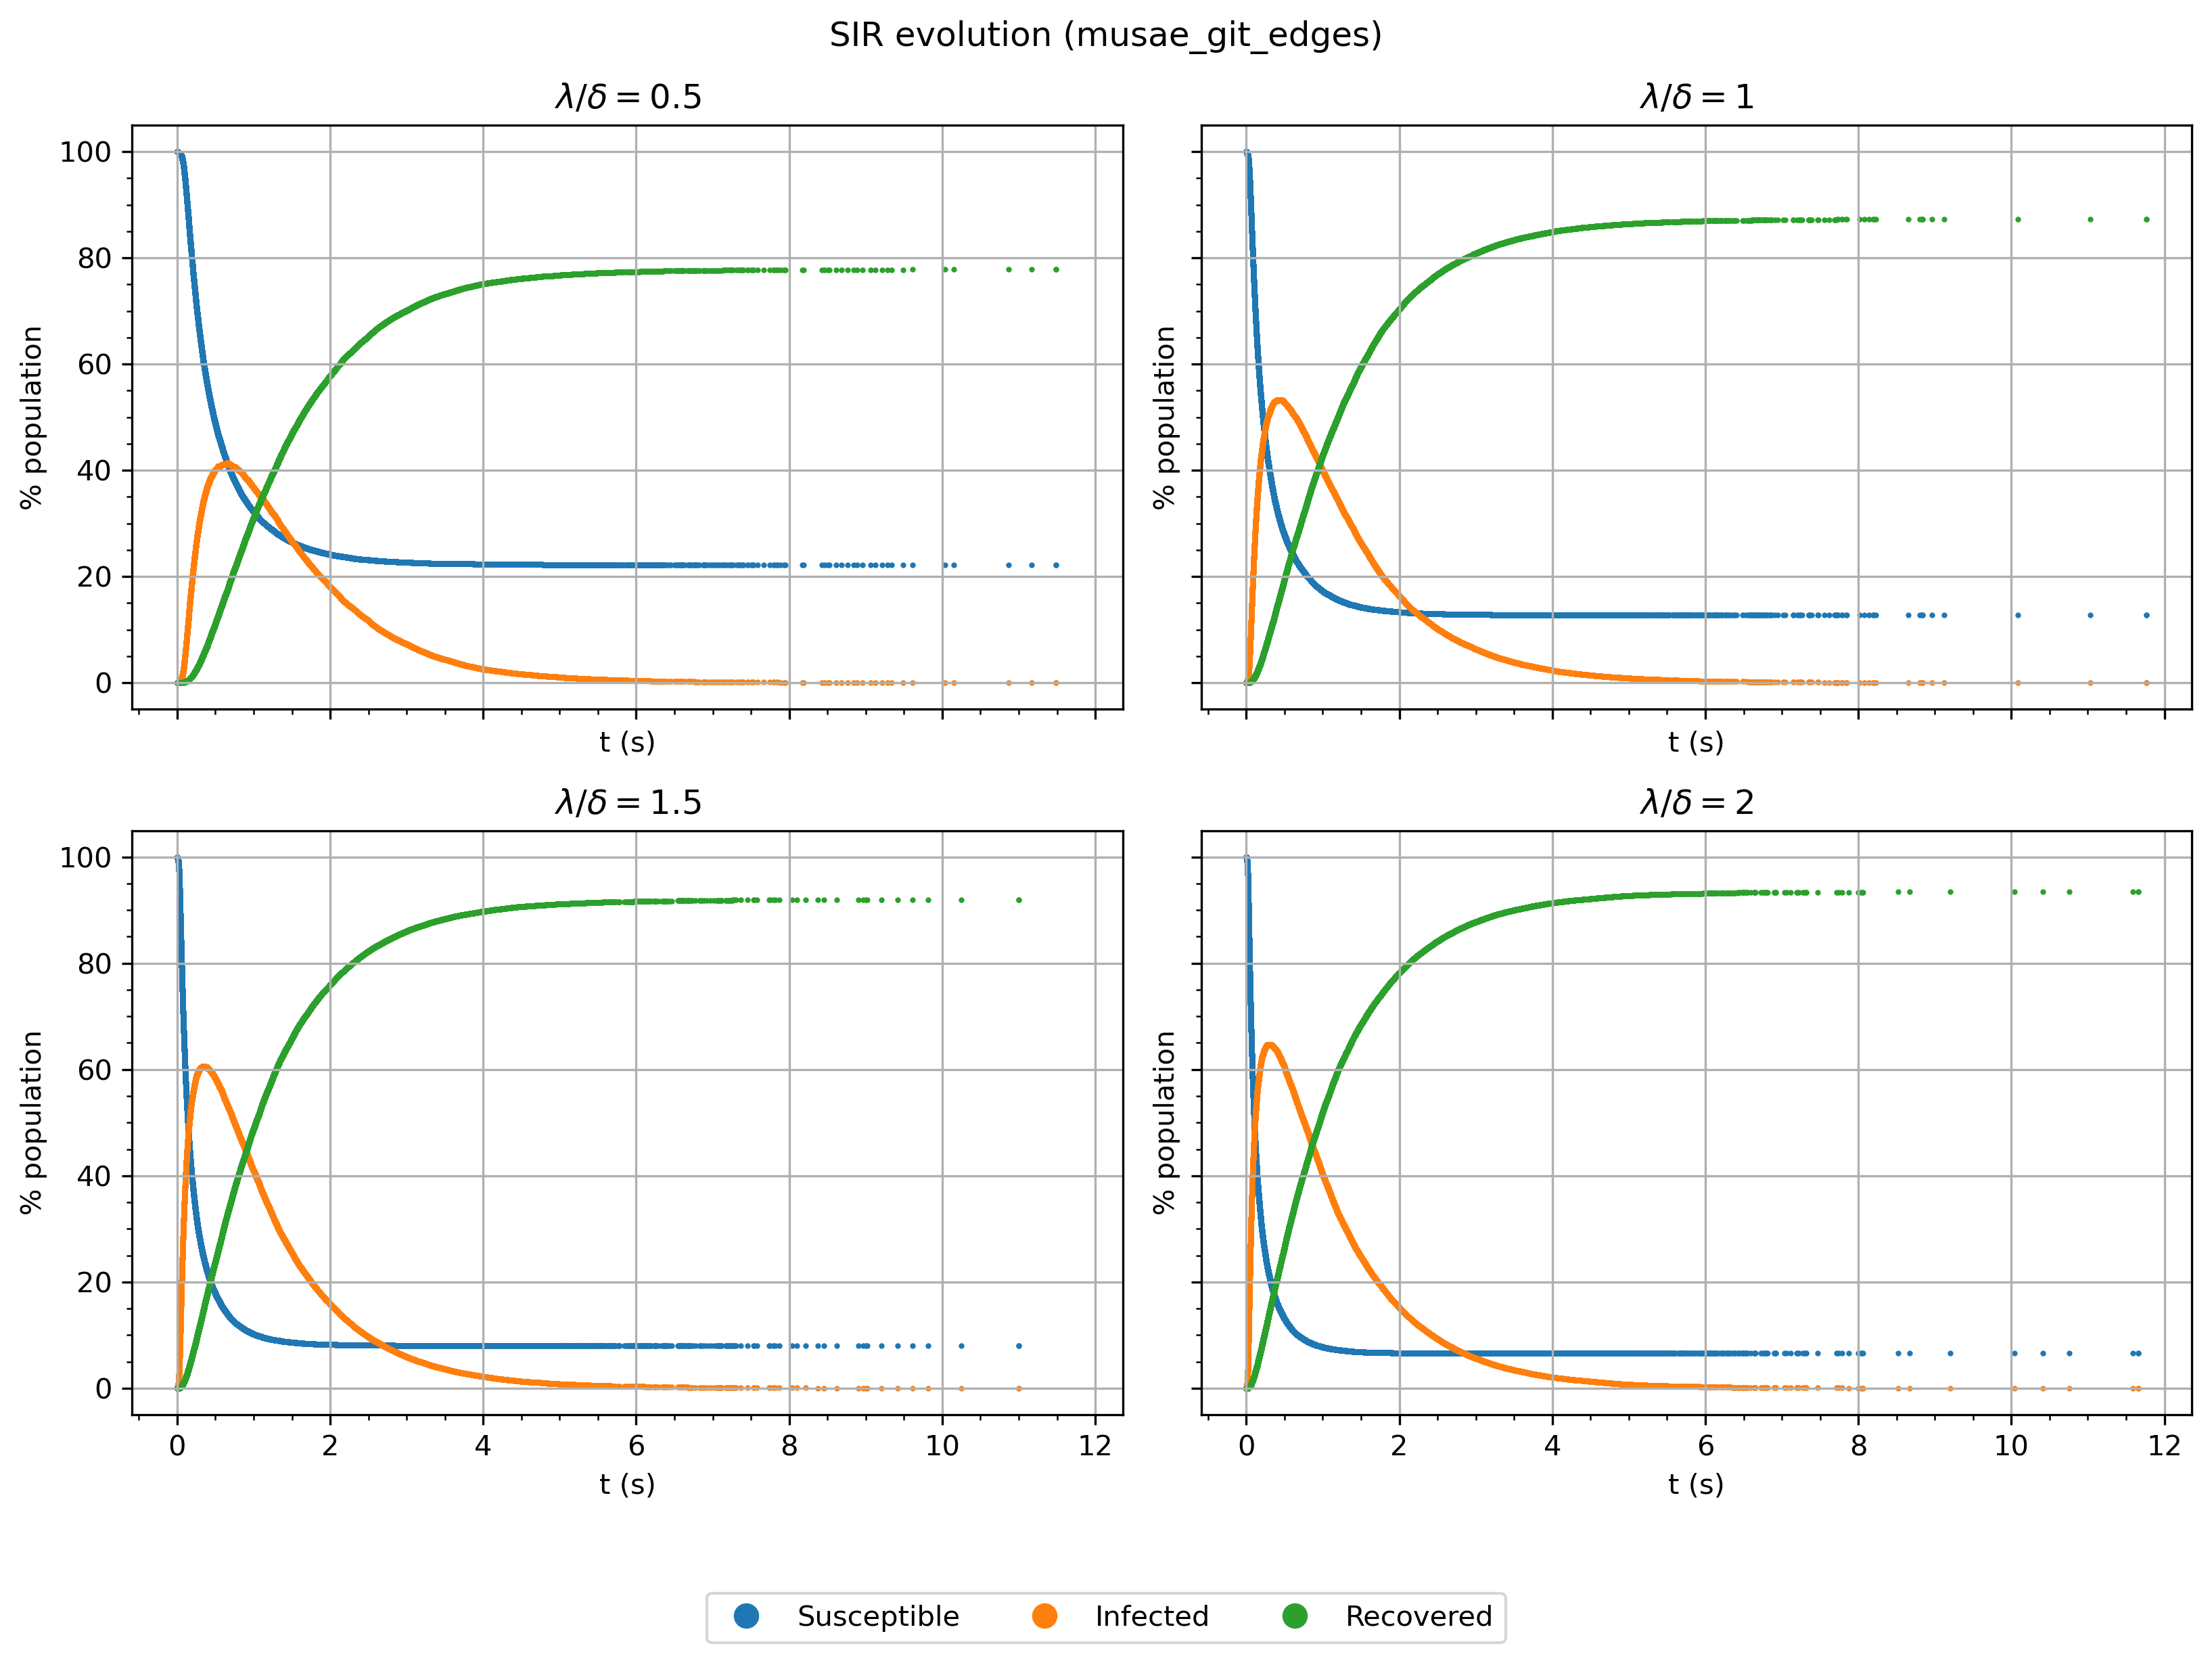

In [14]:
from matplotlib import axes as mpl_ax

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(figsize=(11, 8), dpi=300, nrows=2, ncols=2, sharey=True, sharex=True)

def plot_graph(ax: mpl_ax.Axes, df: pd.DataFrame, title: str):
    ax.minorticks_on()
    ax.scatter(df['t'], df['sdens'], label='Susceptible', s=1)
    ax.scatter(df['t'], df['idens'], label='Infected', s=1)
    ax.scatter(df['t'], df['rdens'], label='Recovered', s=1)
    ax.set_title(title)
    ax.set_xlabel('t (s)')
    ax.set_yticks([i*20/100 for i in range(6)])
    ax.set_yticklabels([str(i*20) for i in range(6)])
    ax.set_ylabel('% population')
    ax.grid()
    # NO incluir leyenda aquí

plot_graph(ax1, df1, r"$\lambda/\delta = 0.5$")
plot_graph(ax2, df2, r"$\lambda/\delta = 1$")
plot_graph(ax3, df3, r"$\lambda/\delta = 1.5$")
plot_graph(ax4, df4, r"$\lambda/\delta = 2$")

# Crear handles personalizados para la leyenda
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
           markersize=8, label='Susceptible', markeredgecolor='tab:blue'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', 
           markersize=8, label='Infected', markeredgecolor='tab:orange'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', 
           markersize=8, label='Recovered', markeredgecolor='tab:green')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)
fig.suptitle("SIR evolution (musae_git_edges)")
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Ajustar espacio para la leyenda
plt.show()